## Curriculum Gap Analysis — Bootstrapped Topic Coverage

This notebook identifies which data science skill areas the UWI B.Sc. Computer Science curriculum does not cover.


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from pathlib import Path
from collections import Counter
 
from gensim.corpora import Dictionary
from gensim.models import LdaModel


In [2]:
# File Paths
BASE = Path("..").resolve()
SKILLS_DIR = BASE / "data" / "skills"

CS_COURSE_PATH          = SKILLS_DIR / "cs_special_course_skills.jsonl"
DATA_SCIENCE_JOBS_PATH  = SKILLS_DIR / "data_science_jobs_skills.jsonl"
UNRELATED_JOBS_PATH     = SKILLS_DIR / "unrelated_jobs_skills.jsonl"

In [3]:
# Data Loading
for path in [CS_COURSE_PATH, DATA_SCIENCE_JOBS_PATH, UNRELATED_JOBS_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"{path} not found.")

cs_course_df     = pd.read_json(CS_COURSE_PATH, lines=True)
data_science_df  = pd.read_json(DATA_SCIENCE_JOBS_PATH, lines=True)
unrelated_df     = pd.read_json(UNRELATED_JOBS_PATH, lines=True)

In [4]:
# Data Preparation

def normalize_multiword_skills(skills):
    if not isinstance(skills, list):
        return []
    return [str(skill).strip().replace(" ", "_") for skill in skills if str(skill).strip()]

def clean_tokens(tokens):
    return [
        t for t in tokens
        if t not in {"computer_science", "information_technology"}
    ]

def prepare_texts(df):
    df = df.copy()
    df["skills"] = df["skills"].apply(normalize_multiword_skills)
    texts = df["skills"].tolist()
    texts = [clean_tokens(t) for t in texts]
    texts = [t for t in texts if len(t) > 0]
    return texts

cs_course_texts     = prepare_texts(cs_course_df)
data_science_texts  = prepare_texts(data_science_df)
unrelated_texts      = prepare_texts(unrelated_df)

print("CS Courses:", len(cs_course_texts))
print("Data Science Jobs:", len(data_science_texts))
print("Unrelated Jobs:", len(unrelated_texts))

CS Courses: 37
Data Science Jobs: 74
Unrelated Jobs: 97


In [5]:
# Number of topics for the data science job corpus.
DS_NUM_TOPICS = 17

# Function to train LDA with a fixed number of topics
def train_lda(skills, num_topics, no_below=1, no_above=0.8):
    dictionary = Dictionary(skills)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)

    corpus = [dictionary.doc2bow(skill) for skill in skills]

    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        iterations=100
    )

    return {
        "dictionary": dictionary,
        "corpus": corpus,
        "model": model
    }

In [6]:
# Topic Scoring

# Function to extract topic words and probabilities
def get_topic_word_probs(model, num_topics, num_words=50):
    topics = model.show_topics(num_topics=num_topics, num_words=num_words, formatted=False)
    topic_word_probs = {}

    for topic_id, word_probs in topics:
        topic_word_probs[topic_id] = dict(word_probs)

    return topic_word_probs


# Function to collapse a list of documents into a single bag of words.
def to_bag(texts):
    return [token for doc in texts for token in doc]


# Function to score one bag of words against every topic.
def score_bag(bag_tokens, topic_word_probs):
    word_counts = Counter(bag_tokens)
    topic_scores = {}

    for topic_id, word_probs in topic_word_probs.items():
        score = 0.0
        for word, prob in word_probs.items():
            if word in word_counts:
                score += word_counts[word] * prob
        topic_scores[topic_id] = score

    return topic_scores

In [7]:
# Bootstrapped Baseline

BOOTSTRAP_ITERS = 1000
RESAMPLE_DOCS   = 96    # the unrelated corpus holds 97 documents
GAP_PERCENTILE  = 5
RANDOM_SEED     = 42


def bootstrap_baseline(docs, topic_word_probs, n_iter=BOOTSTRAP_ITERS,
                       n_docs=RESAMPLE_DOCS, seed=RANDOM_SEED):
    """Sampling distribution of baseline topic scores.

    Returns a DataFrame of shape (n_iter, n_topics).
    """
    rng      = np.random.default_rng(seed)
    n_source = len(docs)
    draws    = []

    for _ in range(n_iter):
        bag = []
        for _ in range(n_docs):
            bag.extend(docs[rng.integers(n_source)])
        draws.append(score_bag(bag, topic_word_probs))

    return pd.DataFrame(draws).sort_index(axis=1)


# Data Science Job Topics

In [8]:
ds_lda = train_lda(data_science_texts, DS_NUM_TOPICS)

print("Data Science Job Topics")
ds_topics = ds_lda["model"].print_topics(num_words=10)
for topic_num, topic_words in ds_topics:
    print(f"\nTopic {topic_num}: {topic_words}")

print("\n" + "="*80 + "\n")

Data Science Job Topics

Topic 0: 0.029*"machine_learning" + 0.025*"feature_engineering" + 0.023*"artificial_intelligence" + 0.020*"creativity" + 0.020*"emerging_technology" + 0.020*"business_analytics" + 0.018*"predictive_modelling" + 0.018*"presentation" + 0.018*"leadership" + 0.017*"business_intelligence"

Topic 1: 0.084*"python" + 0.070*"financial_service" + 0.067*"machine_learning" + 0.065*"sql" + 0.053*"forecasting" + 0.051*"gcp" + 0.036*"writing" + 0.036*"feature_engineering" + 0.036*"plc" + 0.019*"project_manager"

Topic 2: 0.031*"statistics" + 0.031*"machine_learning" + 0.031*"python" + 0.031*"sql" + 0.031*"analytical_skill" + 0.016*"risk_management" + 0.016*"data_engineering" + 0.016*"closing" + 0.016*"leadership" + 0.016*"mentorship"

Topic 3: 0.035*"cloud_technology" + 0.035*"systems_develop" + 0.035*"language_model" + 0.035*"engineering_knowledge" + 0.035*"python" + 0.035*"gcp" + 0.035*"communicate_technical" + 0.035*"operational_efficiency" + 0.035*"scalability" + 0.035*"

In [9]:
# Topic Labels
ds_topic_word_probs = get_topic_word_probs(ds_lda["model"], DS_NUM_TOPICS, num_words=50)

MIN_LABEL_PROB = 0.005   # ignore the long tail, where lift is unstable


def corpus_word_probs(texts):
    """P(w) across the whole corpus, used as the lift denominator."""
    counts = Counter(token for doc in texts for token in doc)
    total  = sum(counts.values())
    return {word: count / total for word, count in counts.items()}


def distinctive_words(topic_word_probs, topic_id, corpus_probs,
                      n_words=3, min_prob=MIN_LABEL_PROB):
    lift = {
        word: prob / corpus_probs.get(word, 1e-9)
        for word, prob in topic_word_probs[topic_id].items()
        if prob >= min_prob
    }
    if not lift:                      # very flat topic -- fall back to probability
        lift = topic_word_probs[topic_id]

    ranked = sorted(lift.items(), key=lambda kv: -kv[1])[:n_words]
    return [word for word, _ in ranked]


ds_corpus_probs = corpus_word_probs(data_science_texts)

DS_TOPIC_LABELS = {
    topic_id: ", ".join(
        w.replace("_", " ")
        for w in distinctive_words(ds_topic_word_probs, topic_id, ds_corpus_probs)
    )
    for topic_id in ds_topic_word_probs
}

print("Data Science Job Topics (labelled by distinctiveness)")
for topic_id in sorted(ds_topic_word_probs):
    most_probable = ", ".join(list(ds_topic_word_probs[topic_id])[:5]).replace("_", " ")
    print(f"\nTopic {topic_id}: {DS_TOPIC_LABELS[topic_id]}")
    print(f"  Most probable: {most_probable}")

Data Science Job Topics (labelled by distinctiveness)

Topic 0: refinement, data exploration, business analytics
  Most probable: machine learning, feature engineering, artificial intelligence, creativity, emerging technology

Topic 1: plc, customer analytics, collection
  Most probable: python, financial service, machine learning, sql, forecasting

Topic 2: analytical skill, projects collaborate, c
  Most probable: statistics, machine learning, python, sql, analytical skill

Topic 3: cloud technology, engineering knowledge, systems develop
  Most probable: cloud technology, systems develop, language model, engineering knowledge, python

Topic 4: delivery focused, postgresql, team leadership
  Most probable: sql, support customer, delivery focused, machine learning, python

Topic 5: sprint planning, tested code, requirements manage
  Most probable: product design, stakeholder management, prototype, github, terraform

Topic 6: economic indicator, requisition, systems thinking
  Most pro

In [10]:
# Bag Construction

cs_bag        = to_bag(cs_course_texts)
unrelated_bag = to_bag(unrelated_texts)

print(f"CS courses bag     : {len(cs_bag):6d} tokens, {len(set(cs_bag)):5d} unique")
print(f"Unrelated jobs bag : {len(unrelated_bag):6d} tokens, {len(set(unrelated_bag)):5d} unique")

# Observed curriculum score for every topic
cs_scores = score_bag(cs_bag, ds_topic_word_probs)

CS courses bag     :   1895 tokens,  1294 unique
Unrelated jobs bag :   1216 tokens,   317 unique


In [11]:
# Bootstrap the unrelated-jobs baseline
baseline = bootstrap_baseline(unrelated_texts, ds_topic_word_probs)
print(f"Bootstrapped {BOOTSTRAP_ITERS} resamples of {RESAMPLE_DOCS} documents "
      f"(with replacement) from {len(unrelated_texts)} unrelated postings.\n")

# 5th-percentile threshold per topic
thresholds = baseline.quantile(GAP_PERCENTILE / 100)

rows = []
for topic_id in sorted(ds_topic_word_probs):
    observed = cs_scores[topic_id]
    p5       = thresholds[topic_id]
    rows.append({
        "Topic":                     topic_id,
        "Label":                     DS_TOPIC_LABELS.get(topic_id, "Unlabeled"),
        "Curriculum Score":          observed,
        f"Baseline P{GAP_PERCENTILE}": p5,
        "Baseline Mean":             baseline[topic_id].mean(),
        "Gap":                       bool(observed < p5),
    })

results_df = (
    pd.DataFrame(rows)
      .sort_values("Curriculum Score", ascending=False)
      .reset_index(drop=True)
)

results_df.round(4)

Bootstrapped 1000 resamples of 96 documents (with replacement) from 97 unrelated postings.



,Topic,Label,Curriculum Score,Baseline P5,Baseline Mean,Gap
0,9,"relational database, recruitment selection, pr...",0.9968,0.4594,0.6257,False
1,15,"engineering statistics, logistics, xgboost",0.8531,0.7126,0.9197,False
2,1,"plc, customer analytics, collection",0.8357,0.2411,0.4377,False
3,8,"building model, integrity information, enthusiasm",0.7073,0.3455,0.5005,False
4,14,"databases embedding, knowledge graph, rest apis",0.7034,0.8867,1.1834,True
5,16,"professional service, strategies business, que...",0.6980,0.6735,0.8100,False
6,6,"economic indicator, requisition, systems thinking",0.6964,0.9984,1.2297,True
7,0,"refinement, data exploration, business analytics",0.6886,1.1994,1.4475,True
8,2,"analytical skill, projects collaborate, c",0.6713,1.1498,1.5136,True
9,13,"signal processing, business analysis, analysis...",0.6664,0.2059,0.3797,False


In [12]:
# Gap Classification
gaps_df = results_df[results_df["Gap"]]

print(f"{len(gaps_df)} of {len(results_df)} topics classified as gaps -- curriculum "
      f"score below the {GAP_PERCENTILE}th percentile of the bootstrapped baseline.\n")

if len(gaps_df):
    print(gaps_df[["Topic", "Label", "Curriculum Score", f"Baseline P{GAP_PERCENTILE}"]]
          .round(4).to_string(index=False))
else:
    print("No topics classified as gaps.")

7 of 17 topics classified as gaps -- curriculum score below the 5th percentile of the bootstrapped baseline.

 Topic                                                Label  Curriculum Score  Baseline P5
    14      databases embedding, knowledge graph, rest apis            0.7034       0.8867
     6    economic indicator, requisition, systems thinking            0.6964       0.9984
     0     refinement, data exploration, business analytics            0.6886       1.1994
     2            analytical skill, projects collaborate, c            0.6713       1.1498
    12    business acumen, testing regression, google cloud            0.6274       1.0692
     7 analysis business, benchmarking, strategies business            0.5355       0.9312
     5    sprint planning, tested code, requirements manage            0.4479       0.7422


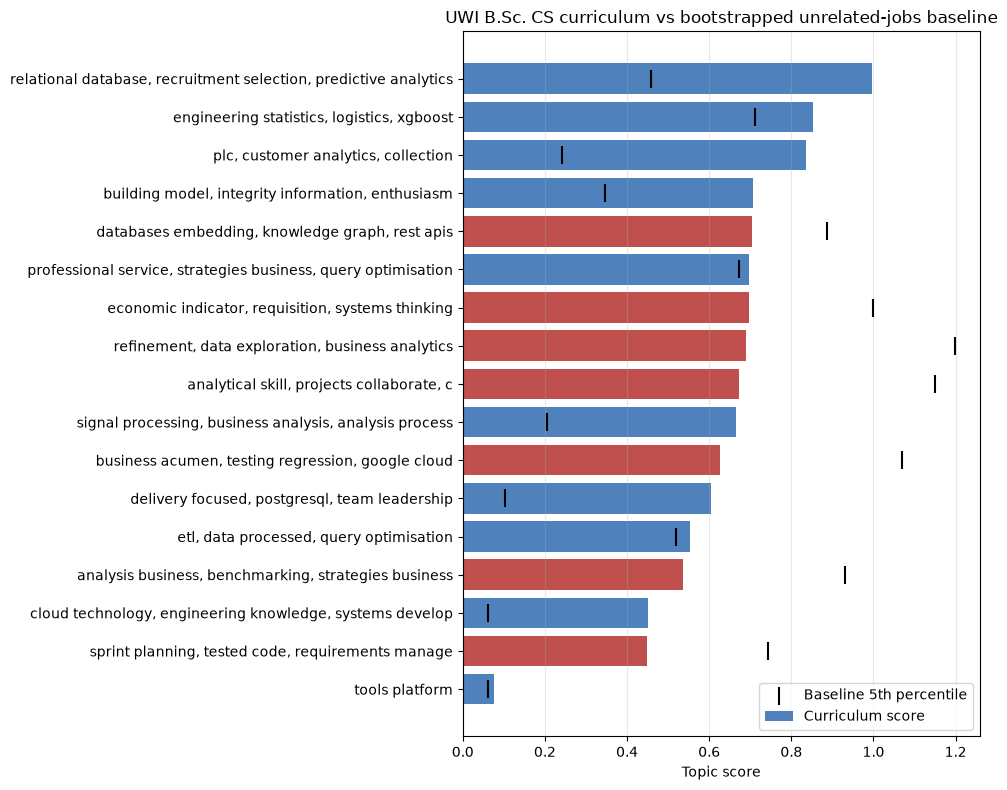

In [13]:
# Curriculum score against the bootstrapped baseline threshold
plot_df = results_df.sort_values("Curriculum Score")

fig, ax = plt.subplots(figsize=(10, 8))
y = range(len(plot_df))
colors = ["#C0504D" if g else "#4F81BD" for g in plot_df["Gap"]]

ax.barh(y, plot_df["Curriculum Score"], color=colors, label="Curriculum score")
ax.scatter(plot_df[f"Baseline P{GAP_PERCENTILE}"], y, color="black", marker="|",
           s=180, zorder=3, label=f"Baseline {GAP_PERCENTILE}th percentile")

ax.set_yticks(list(y))
ax.set_yticklabels(plot_df["Label"])
ax.set_xlabel("Topic score")
ax.set_title("UWI B.Sc. CS curriculum vs bootstrapped unrelated-jobs baseline")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()